In [1]:
import pandas as pd
import numpy as np
import scanpy as sc 
import celltypist
from celltypist import models
import warnings 

warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

import celltypist
import anndata as ad

import seaborn as sns
import matplotlib.pyplot as plt

/home/senthilkumar/anaconda3/lib/python3.13/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [2]:
seurat_processed = ad.read_h5ad("/media/senthilkumar/New/scRNA-Seq_Workshop/Bonus_data/output/GSE183276_seurat_processed.h5ad")
seurat_processed

AnnData object with n_obs × n_vars = 97452 × 29447
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'barcodes', 'library', 'percent.er', 'percent.mt', 'degen.score', 'aEpi.score', 'aStr.score', 'cyc.score', 'matrisome.score', 'collagen.score', 'glycoprotein.score', 'proteoglycan.score', 'S.Score', 'G2M.Score', 'Phase', 'experiment', 'experiment.short', 'specimen', 'condition.long', 'condition.l1', 'condition.l2', 'condition.l3', 'patient', 'region.l1', 'region.l2', 'percent.cortex', 'percent.medulla', 'sex', 'race', 'tissue_type', 'assay', 'location', 'laterality', 'snDrop_predicted_subclass', 'snDrop_prediction_score', 'clusters', 'id', 'predicted.class.score', 'predicted.class', 'predicted.subclass.l1.score', 'predicted.subclass.l1', 'predicted.subclass.l3.score', 'predicted.subclass.l3', 'sc.subclass.l2', 'pagoda_k100_infomap_coembed', 'subclass.full', 'subclass.l3', 'subclass.l2', 'subclass.l1', 'state.l2', 'state', 'class', 'structure', 'tal.module', 'pt.module', 'percent.rb',

In [2]:
harmony_processed = ad.read_h5ad("/media/senthilkumar/New/scRNA-Seq_Workshop/Bonus_data/output/GSE183276_harmony_processed.h5ad")
harmony_processed

AnnData object with n_obs × n_vars = 97452 × 29447
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'barcodes', 'library', 'percent.er', 'percent.mt', 'degen.score', 'aEpi.score', 'aStr.score', 'cyc.score', 'matrisome.score', 'collagen.score', 'glycoprotein.score', 'proteoglycan.score', 'S.Score', 'G2M.Score', 'Phase', 'experiment', 'experiment.short', 'specimen', 'condition.long', 'condition.l1', 'condition.l2', 'condition.l3', 'patient', 'region.l1', 'region.l2', 'percent.cortex', 'percent.medulla', 'sex', 'race', 'tissue_type', 'assay', 'location', 'laterality', 'snDrop_predicted_subclass', 'snDrop_prediction_score', 'clusters', 'id', 'predicted.class.score', 'predicted.class', 'predicted.subclass.l1.score', 'predicted.subclass.l1', 'predicted.subclass.l3.score', 'predicted.subclass.l3', 'sc.subclass.l2', 'pagoda_k100_infomap_coembed', 'subclass.full', 'subclass.l3', 'subclass.l2', 'subclass.l1', 'state.l2', 'state', 'class', 'structure', 'tal.module', 'pt.module', 'percent.rb',

(97452, 2)


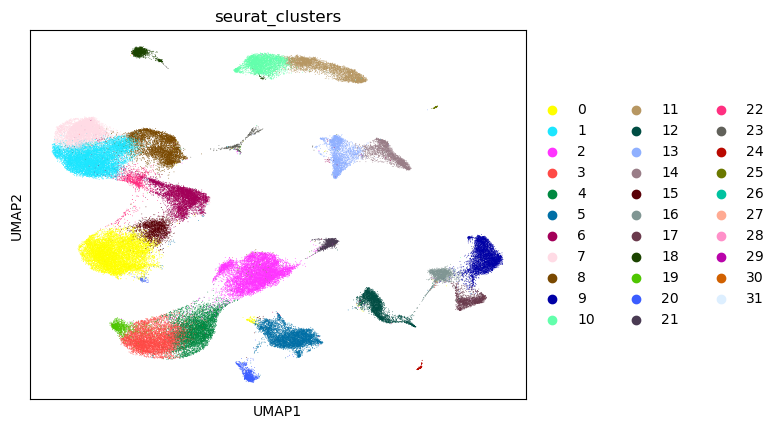

In [3]:
umap_df = pd.read_csv("/media/senthilkumar/New/scRNA-Seq_Workshop/Bonus_data/output/GSE183276_harmony_umap_coordinates.csv", index_col=0)
print(umap_df.shape)

harmony_processed.obsm['X_umap'] = umap_df.loc[harmony_processed.obs_names].values
sc.pl.umap(harmony_processed, color="seurat_clusters", show=True)

In [4]:
harmony_processed.X = harmony_processed.layers['logcounts'].copy()

In [5]:
subset_adata = harmony_processed[::3].copy() 

predictions = celltypist.annotate(
    subset_adata, 
    model = "/media/senthilkumar/New/scRNA-Seq_Workshop/Adult_Human_Kidney.pkl", 
    majority_voting = True,
    over_clustering = "seurat_clusters"
)


🔬 Input data has 32484 cells and 29447 genes
🔗 Matching reference genes in the model
🧬 10061 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
🗳️ Majority voting the predictions
✅ Majority voting done!


In [6]:
cell_labels = predictions.predicted_labels['majority_voting'].to_dict()
cell_labels

{'AKI3010018_AAACCCACAGGGATAC-1': 'aPT',
 'AKI3010018_AAACGCTAGCTTTCTT-1': 'T cells',
 'AKI3010018_AAAGGATGTGGCAGAT-1': 'DC',
 'AKI3010018_AAAGGTAAGCTCTTCC-1': 'B cells',
 'AKI3010018_AAAGTCCCATGAGTAA-1': 'B cells',
 'AKI3010018_AAAGTGACACGGATCC-1': 'aPT',
 'AKI3010018_AACAAGACACTACCGG-1': 'aTAL',
 'AKI3010018_AACAAGATCCCGTTGT-1': 'PT',
 'AKI3010018_AACCAACGTAAGGCTG-1': 'T cells',
 'AKI3010018_AACCCAACACGGTCTG-1': 'aPT',
 'AKI3010018_AACCTGATCCGGCTTT-1': 'T cells',
 'AKI3010018_AACGGGAAGGCCCAAA-1': 'aTAL',
 'AKI3010018_AACGTCACAGACCTGC-1': 'T cells',
 'AKI3010018_AAGAACAAGATCGGTG-1': 'DC',
 'AKI3010018_AAGAACATCGTTCCTG-1': 'PT',
 'AKI3010018_AAGACAACAGCTGTCG-1': 'aPT',
 'AKI3010018_AAGCATCCAGAACATA-1': 'EC-PTC',
 'AKI3010018_AAGCCATAGGGAACAA-1': 'B cells',
 'AKI3010018_AAGCGAGTCTCAGAAC-1': 'aPT',
 'AKI3010018_AAGGAATCAGCAATTC-1': 'PC',
 'AKI3010018_AAGGTAAAGCTCCGAC-1': 'B cells',
 'AKI3010018_AAGTACCAGGCTCTAT-1': 'PT',
 'AKI3010018_AAGTCGTTCAGGAAAT-1': 'DCT',
 'AKI3010018_AAGTGAAAGGTGC

In [10]:
subset_adata.obs['cell_type'] = subset_adata.obs.index.map(cell_labels)

In [26]:
subset_adata.obs[['cell_type', 'seurat_clusters']].head(10)

,cell_type,seurat_clusters
AKI3010018_AAACCCACAGGGATAC-1,aPT,2
AKI3010018_AAACGCTAGCTTTCTT-1,T cells,10
AKI3010018_AAAGGATGTGGCAGAT-1,DC,13
AKI3010018_AAAGGTAAGCTCTTCC-1,B cells,18
AKI3010018_AAAGTCCCATGAGTAA-1,B cells,18
AKI3010018_AAAGTGACACGGATCC-1,aPT,2
AKI3010018_AACAAGACACTACCGG-1,aTAL,8
AKI3010018_AACAAGATCCCGTTGT-1,PT,4
AKI3010018_AACCAACGTAAGGCTG-1,T cells,11
AKI3010018_AACCCAACACGGTCTG-1,aPT,2


In [29]:
subset_adata.obs['seurat_clusters'].dtype

CategoricalDtype(categories=['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11',
                  '12', '13', '14', '15', '16', '17', '18', '19', '20', '21',
                  '22', '23', '24', '25', '26', '27', '28', '29'],
, ordered=False, categories_dtype=object)

In [51]:
# Create a list of clusters you want to inspect
target_clusters = ['3', '4']

# Filter and select your columns
check_view = subset_adata.obs[subset_adata.obs['seurat_clusters'].isin(target_clusters)]

# Print the top 10 results
print(check_view[['cell_type', 'seurat_clusters']].head(50))

                              cell_type seurat_clusters
AKI3010018_AACAAGATCCCGTTGT-1        PT               4
AKI3010018_AAGAACATCGTTCCTG-1        PT               4
AKI3010018_AAGTACCAGGCTCTAT-1        PT               3
AKI3010018_ACGGTTAAGGTGCGAT-1        PT               4
AKI3010018_ACGTACAAGTGCCCGT-1        PT               3
AKI3010018_ACTGTGAAGAGTCGAC-1        PT               3
AKI3010018_ACTTATCGTTGCACGC-1        PT               4
AKI3010018_ACTTTGTAGCACTAGG-1        PT               4
AKI3010018_AGAGCCCTCGAGATGG-1        PT               4
AKI3010018_AGCATCAAGCTTTCCC-1        PT               3
AKI3010018_AGCCACGGTCAGTCCG-1        PT               4
AKI3010018_AGGAATACATGAGAAT-1        PT               4
AKI3010018_AGTCATGAGTTCGCAT-1        PT               4
AKI3010018_AGTTCCCGTACTCCGG-1        PT               3
AKI3010018_ATACTTCGTTTACTTC-1        PT               4
AKI3010018_ATCCGTCGTACTAGCT-1        PT               3
AKI3010018_ATTTCTGTCGAAGAAT-1        PT         

In [42]:
cell_labels = subset_adata.obs.groupby('seurat_clusters')['cell_type'].agg(lambda x: x.value_counts().index[0]).to_dict()

In [ ]:
harmony_processed.obs['cell_type'] = harmony_processed.obs['seurat_clusters'].astype(str).map(cell_labels)

In [48]:
harmony_processed.obs['cell_type'].isna().sum()

np.int64(4)

In [ ]:
harmony_processed.obs['cell_type']=harmony_processed.obs['cell_type'].fillna('Unknown')

,orig.ident,nCount_RNA,nFeature_RNA,barcodes,library,percent.er,percent.mt,degen.score,aEpi.score,aStr.score,...,structure,tal.module,pt.module,percent.rb,mahalanobis_values,kidney_UMAP,kidney_harmony_res.0.8,seurat_clusters,ident,cell_type


Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'barcodes', 'library',
       'percent.er', 'percent.mt', 'degen.score', 'aEpi.score', 'aStr.score',
       'cyc.score', 'matrisome.score', 'collagen.score', 'glycoprotein.score',
       'proteoglycan.score', 'S.Score', 'G2M.Score', 'Phase', 'experiment',
       'experiment.short', 'specimen', 'condition.long', 'condition.l1',
       'condition.l2', 'condition.l3', 'patient', 'region.l1', 'region.l2',
       'percent.cortex', 'percent.medulla', 'sex', 'race', 'tissue_type',
       'assay', 'location', 'laterality', 'snDrop_predicted_subclass',
       'snDrop_prediction_score', 'clusters', 'id', 'predicted.class.score',
       'predicted.class', 'predicted.subclass.l1.score',
       'predicted.subclass.l1', 'predicted.subclass.l3.score',
       'predicted.subclass.l3', 'sc.subclass.l2',
       'pagoda_k100_infomap_coembed', 'subclass.full', 'subclass.l3',
       'subclass.l2', 'subclass.l1', 'state.l2', 'state', 'class', 'structure',
  

In [61]:
harmony_processed.obs['cell_type'].value_counts()

cell_type
C-TAL                      15847
PT                         13739
PC                         11128
aPT                        10888
T cells                     7710
aTAL                        6082
CCD-IC-A                    5581
DCT                         5373
EC-PTC                      4795
VSMC/P                      3219
DC                          3113
Non-classical monocytes     2253
CNT                         1944
EC-GC                       1573
EC-DVR                      1558
B cells                     1345
IC-B                        1053
Podocytes                    245
Unknown                        4
dVSMC                          2
Name: count, dtype: int64

... storing 'cell_type' as categorical


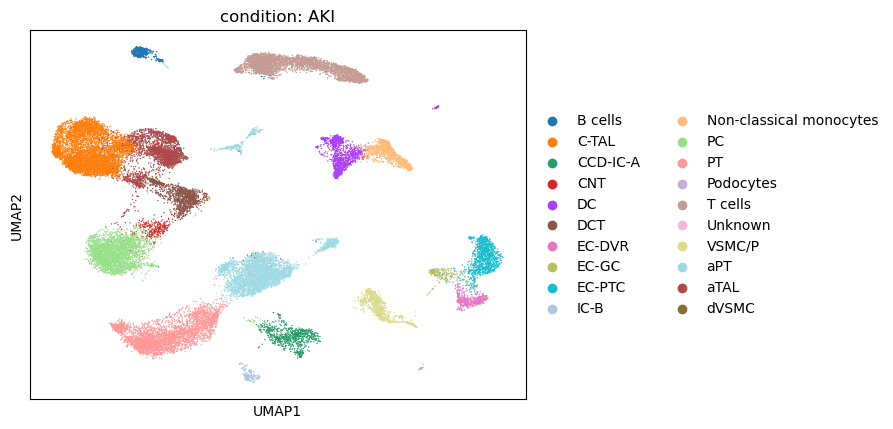

... storing 'cell_type' as categorical


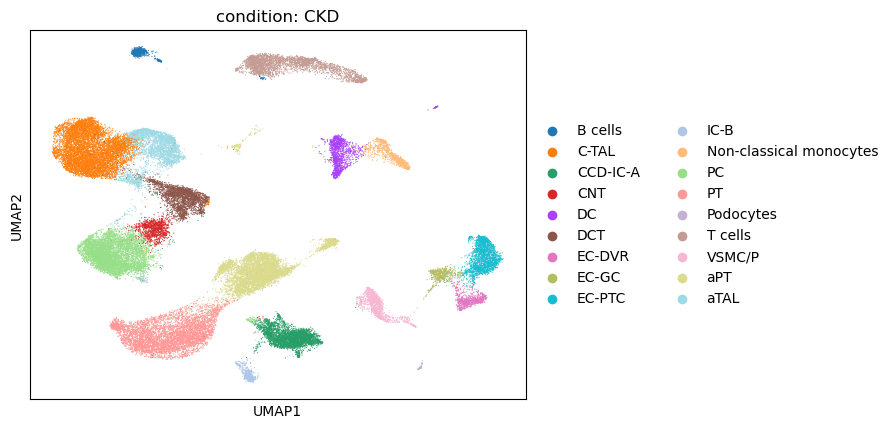

... storing 'cell_type' as categorical


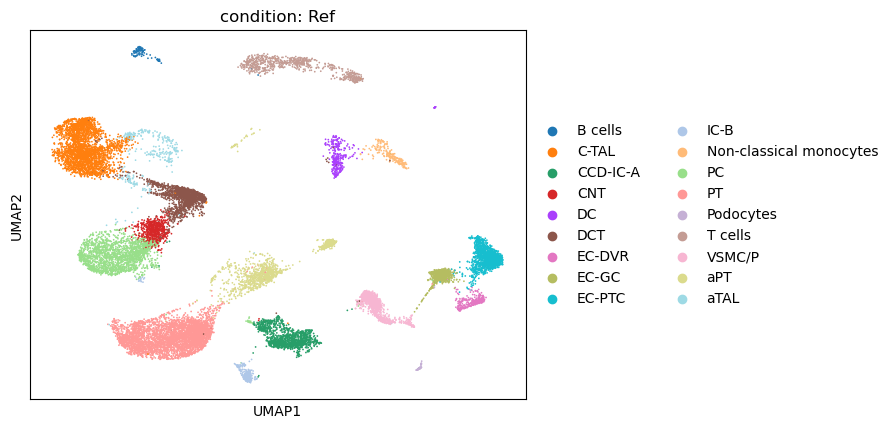

In [65]:
for cond in harmony_processed.obs['condition.l1'].unique():
    fig =  sc.pl.umap(harmony_processed[harmony_processed.obs['condition.l1']==cond], color='cell_type', title=f'condition: {cond}', show=False, legend_loc='right margin', return_fig=True)
    plt.show()

In [3]:
seurat_processed.X = seurat_processed.layers['logcounts'].copy()
seurat_processed

AnnData object with n_obs × n_vars = 97452 × 29447
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'barcodes', 'library', 'percent.er', 'percent.mt', 'degen.score', 'aEpi.score', 'aStr.score', 'cyc.score', 'matrisome.score', 'collagen.score', 'glycoprotein.score', 'proteoglycan.score', 'S.Score', 'G2M.Score', 'Phase', 'experiment', 'experiment.short', 'specimen', 'condition.long', 'condition.l1', 'condition.l2', 'condition.l3', 'patient', 'region.l1', 'region.l2', 'percent.cortex', 'percent.medulla', 'sex', 'race', 'tissue_type', 'assay', 'location', 'laterality', 'snDrop_predicted_subclass', 'snDrop_prediction_score', 'clusters', 'id', 'predicted.class.score', 'predicted.class', 'predicted.subclass.l1.score', 'predicted.subclass.l1', 'predicted.subclass.l3.score', 'predicted.subclass.l3', 'sc.subclass.l2', 'pagoda_k100_infomap_coembed', 'subclass.full', 'subclass.l3', 'subclass.l2', 'subclass.l1', 'state.l2', 'state', 'class', 'structure', 'tal.module', 'pt.module', 'percent.rb',

In [4]:
seurat_subset = seurat_processed[::3]
seurat_predictions = celltypist.annotate(seurat_subset, model="/media/senthilkumar/New/scRNA-Seq_Workshop/Adult_Human_Kidney.pkl", majority_voting=True)

🔬 Input data has 32484 cells and 29447 genes
🔗 Matching reference genes in the model
🧬 10061 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 15
🗳️ Majority voting the predictions
✅ Majority voting done!


In [5]:
seurat_labels = seurat_predictions.predicted_labels['majority_voting'].to_dict()

In [6]:
from sklearn.neighbors import KNeighborsClassifier
X_train = seurat_subset.obsm['PCA']
Y_train = seurat_predictions.predicted_labels['majority_voting']
knn = KNeighborsClassifier(n_neighbors=20)
knn.fit(X_train, Y_train)


,n_neighbors,20
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [7]:
seurat_subset

AnnData object with n_obs × n_vars = 32484 × 29447
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'barcodes', 'library', 'percent.er', 'percent.mt', 'degen.score', 'aEpi.score', 'aStr.score', 'cyc.score', 'matrisome.score', 'collagen.score', 'glycoprotein.score', 'proteoglycan.score', 'S.Score', 'G2M.Score', 'Phase', 'experiment', 'experiment.short', 'specimen', 'condition.long', 'condition.l1', 'condition.l2', 'condition.l3', 'patient', 'region.l1', 'region.l2', 'percent.cortex', 'percent.medulla', 'sex', 'race', 'tissue_type', 'assay', 'location', 'laterality', 'snDrop_predicted_subclass', 'snDrop_prediction_score', 'clusters', 'id', 'predicted.class.score', 'predicted.class', 'predicted.subclass.l1.score', 'predicted.subclass.l1', 'predicted.subclass.l3.score', 'predicted.subclass.l3', 'sc.subclass.l2', 'pagoda_k100_infomap_coembed', 'subclass.full', 'subclass.l3', 'subclass.l2', 'subclass.l1', 'state.l2', 'state', 'class', 'structure', 'tal.module', 'pt.module', 'percent.rb',

In [8]:
seurat_processed

AnnData object with n_obs × n_vars = 97452 × 29447
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'barcodes', 'library', 'percent.er', 'percent.mt', 'degen.score', 'aEpi.score', 'aStr.score', 'cyc.score', 'matrisome.score', 'collagen.score', 'glycoprotein.score', 'proteoglycan.score', 'S.Score', 'G2M.Score', 'Phase', 'experiment', 'experiment.short', 'specimen', 'condition.long', 'condition.l1', 'condition.l2', 'condition.l3', 'patient', 'region.l1', 'region.l2', 'percent.cortex', 'percent.medulla', 'sex', 'race', 'tissue_type', 'assay', 'location', 'laterality', 'snDrop_predicted_subclass', 'snDrop_prediction_score', 'clusters', 'id', 'predicted.class.score', 'predicted.class', 'predicted.subclass.l1.score', 'predicted.subclass.l1', 'predicted.subclass.l3.score', 'predicted.subclass.l3', 'sc.subclass.l2', 'pagoda_k100_infomap_coembed', 'subclass.full', 'subclass.l3', 'subclass.l2', 'subclass.l1', 'state.l2', 'state', 'class', 'structure', 'tal.module', 'pt.module', 'percent.rb',

In [7]:
X_all = seurat_processed.obsm['PCA']
seurat_processed.obs['predicted_cell_type'] = knn.predict(X_all)
#knn.predict(X_all)

In [10]:
print(seurat_processed.obs.groupby('predicted_cell_type').size())

predicted_cell_type
B cells                     1206
C-TAL                      17099
CCD-IC-A                    6276
CNT                         3898
Classical monocytes          857
DC                          2676
DC2                          329
DCT                         4917
DTL                         1155
EC-AEA                       738
EC-DVR                       966
EC-GC                       1452
EC-PTC                      4721
IC-B                         915
M-TAL                       1376
NK cells                     760
Non-classical monocytes     1352
PC                          7874
PT                         12052
Podocytes                    215
T cells                     7111
VSMC/P                      1908
aPT                        12348
aTAL                        3508
dC-IC-A                      592
dVSMC                       1151
dtype: int64


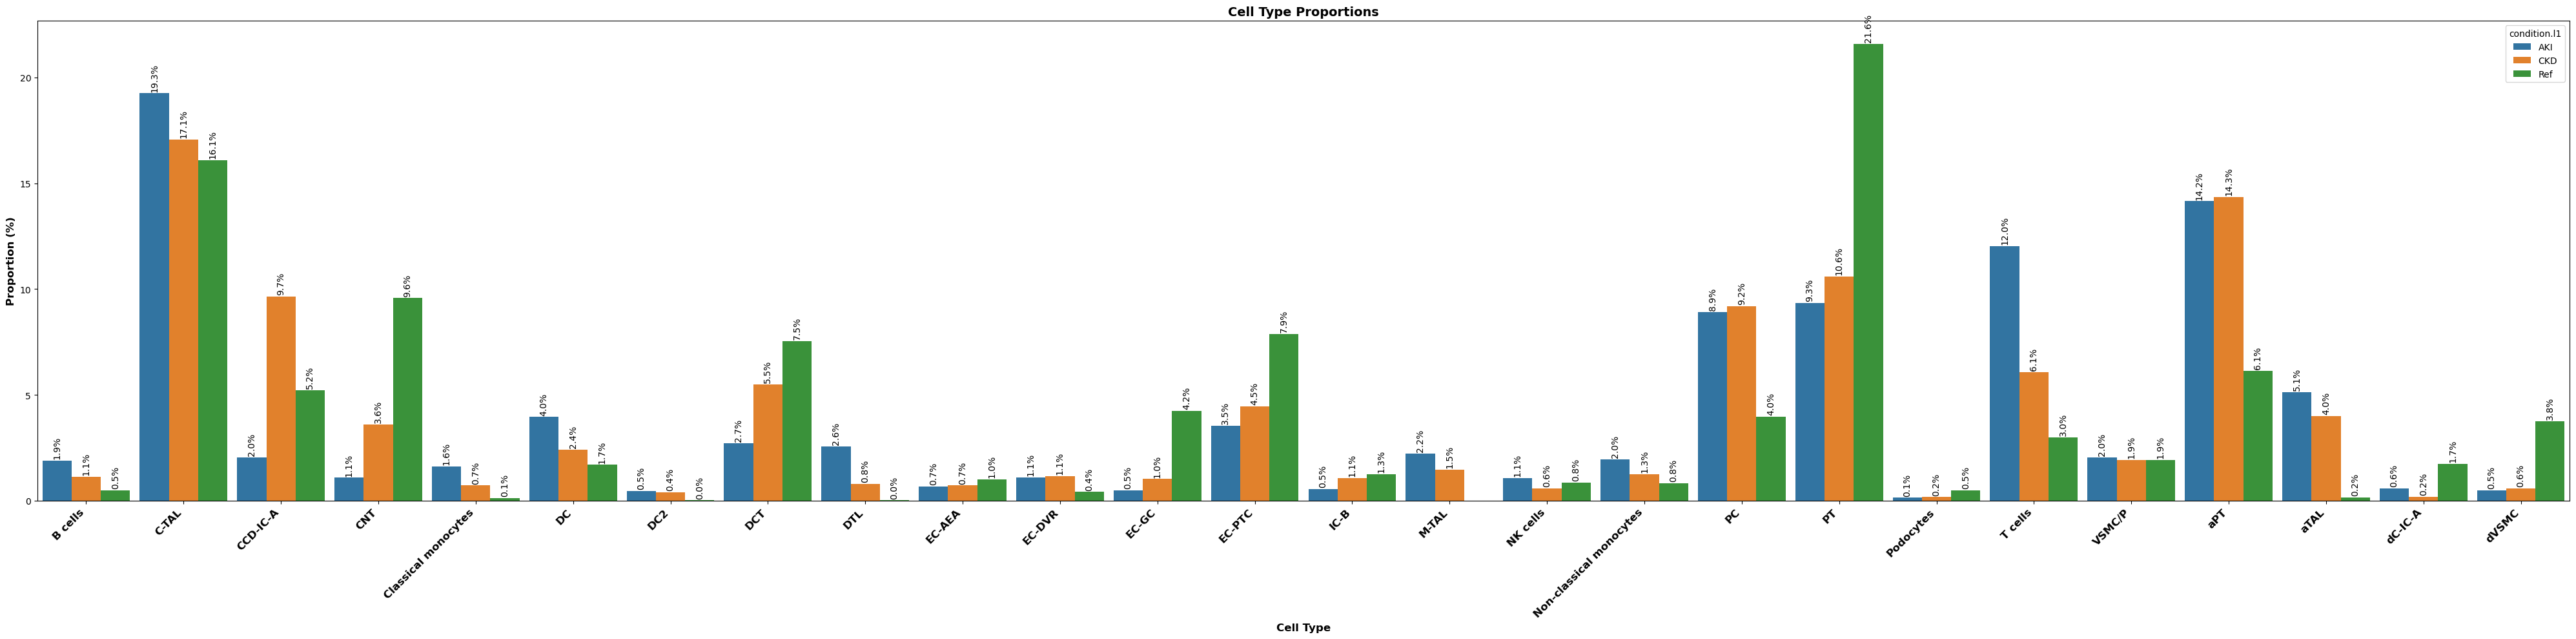

In [8]:
ncell_condition = seurat_processed.obs.groupby(['condition.l1','predicted_cell_type'], observed=True).size().reset_index(name='Count')
ncell_condition['total'] = ncell_condition.groupby('condition.l1')['Count'].transform(sum)
ncell_condition['proportion'] = (ncell_condition['Count'] / ncell_condition['total'])* 100

#find the average proportions of cells per group
average_proportions = ncell_condition.groupby('predicted_cell_type')['proportion'].mean().sort_values(ascending=False)
cell_type_order = average_proportions.index.to_list()

#ncell_condition.to_csv("/media/senthilkumar/New/scRNA-Seq_Workshop/Bonus_data/output/Cellproportions.csv", index=False)

plt.figure(figsize=(40,10))
ax= sns.barplot(data=ncell_condition, 
                x="predicted_cell_type", 
                y="proportion", 
                hue="condition.l1", 
                dodge=True, 
                width=0.9)

for container in ax.containers:ax.bar_label(container, 
                                            fmt="%.1f%%", 
                                            label_type='edge', 
                                            padding=2, 
                                            fontsize=10, 
                                            rotation = 90 )
    
plt.xticks(rotation=45, ha = "right", fontsize = 12, fontweight = "bold")
plt.ylabel("Proportion (%)", fontsize=12, fontweight="bold")
plt.xlabel("Cell Type", fontsize=12, fontweight="bold")
plt.title("Cell Type Proportions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/media/senthilkumar/New/scRNA-Seq_Workshop/Bonus_data/plots/cellproportions_barplot.png", dpi=300, bbox_inches='tight')
plt.show()


In [9]:
seurat_processed.obs['majority_voting'] = seurat_processed.obs['predicted_cell_type'].astype(str)+"_"+seurat_processed.obs['condition.l1'].astype(str)
seurat_processed.obs['majority_voting']

AKI3010018_AAACCCACAGGGATAC-1              aPT_AKI
AKI3010018_AAACCCATCTGATGGT-1           EC-AEA_AKI
AKI3010018_AAACCCATCTGCTTTA-1              aPT_AKI
AKI3010018_AAACGCTAGCTTTCTT-1          T cells_AKI
AKI3010018_AAACGCTGTCACCGAC-1               PC_AKI
                                          ...     
LDSample1162EO2_TTTGATCGTGAGTAGC-1      EC-PTC_Ref
LDSample1162EO2_TTTGGAGAGCAGGCAT-1         CNT_Ref
LDSample1162EO2_TTTGGAGAGTGCTCGC-1          PT_Ref
LDSample1162EO2_TTTGGAGGTGATACTC-1    CCD-IC-A_Ref
LDSample1162EO2_TTTGGTTCAGTAGAAT-1       C-TAL_Ref
Name: majority_voting, Length: 97452, dtype: object

In [10]:
def find_unique_markers (seurat_processed,
                         group_by = "majority_voting",
                         method = 'wilcoxon',
                         pval_threshold = 0.05,
                         logfc_threshold = 0.25,
                         top_n = 3,
                         min_cellspergroup = 4):
    group_counts = seurat_processed.obs['majority_voting'].value_counts()
    valid_groups = group_counts[group_counts >= min_cellspergroup].index.to_list()
    group_counts = seurat_processed.obs['majority_voting'].value_counts()
    valid_groups = group_counts[group_counts >= 2].index.to_list()
    seurat_filtered = seurat_processed[seurat_processed.obs['majority_voting'].isin(valid_groups)]

    sc.tl.rank_genes_groups(seurat_filtered, groupby=group_by, method=method)
    all_degs = sc.get.rank_genes_groups_df(seurat_filtered, group=None)
    #filtered_degs = all_degs[(all_degs['pvals_adg'] < pval_threshold) & (abs(all_degs['adglogfoldchanges'] > logfc_threshold))]
    filtered_degs = all_degs[(all_degs['pvals_adj'] < pval_threshold) & (all_degs['logfoldchanges'].abs() > logfc_threshold)]
    unique_degs = filtered_degs.groupby('names')['group'].nunique().reset_index().query('group==1')['names'].tolist()

    unique_degs_df = filtered_degs[filtered_degs['names'].isin(unique_degs)].copy()

    #top_unique_degs = (unique_degs_df.sort_values(['group', 'logfoldchanges'], ascending=[True, False]).group_by('group')
    #                                 .head(top_n)
    #                                .reset_index(drop=True)
    #)
    top_unique_degs = (unique_degs_df
                       .sort_values(['group','logfoldchanges'], ascending=[True, False])
                       .groupby('group')
                       .head(top_n)
                       .reset_index(drop = True)
                       )

    return top_unique_degs

   
    
    

In [11]:
unique_markers = find_unique_markers(seurat_processed=seurat_processed)



... storing 'predicted_cell_type' as categorical
... storing 'majority_voting' as categorical


In [12]:
unique_markers['group'] = unique_markers['group'].str.replace(r'_(AKI | CKD | Ref)_\1$', r'_\1', regex=True)
print(unique_markers.head())
unique_markers['group'].drop_duplicates()
unique_markers
unique_markers.to_csv("/media/senthilkumar/New/scRNA-Seq_Workshop/Bonus_data/output/Unique_cluster_markers.csv", index=False)

         group          names    scores  logfoldchanges     pvals  pvals_adj
0  B cells_AKI         NIBAN3  3.534678        8.158079  0.000408   0.004117
1  B cells_AKI          IGLL5  3.062342        6.047616  0.002196   0.018822
2  B cells_AKI          SNX22  4.023551        5.730336  0.000057   0.000686
3  B cells_CKD           CNR2  3.002196        6.803649  0.002680   0.022177
4  B cells_Ref  RP11-693J15.5  3.243109        9.524583  0.001182   0.041383


In [13]:
unique_markers.columns

Index(['group', 'names', 'scores', 'logfoldchanges', 'pvals', 'pvals_adj'], dtype='object')

... storing 'predicted_cell_type' as categorical
... storing 'majority_voting' as categorical


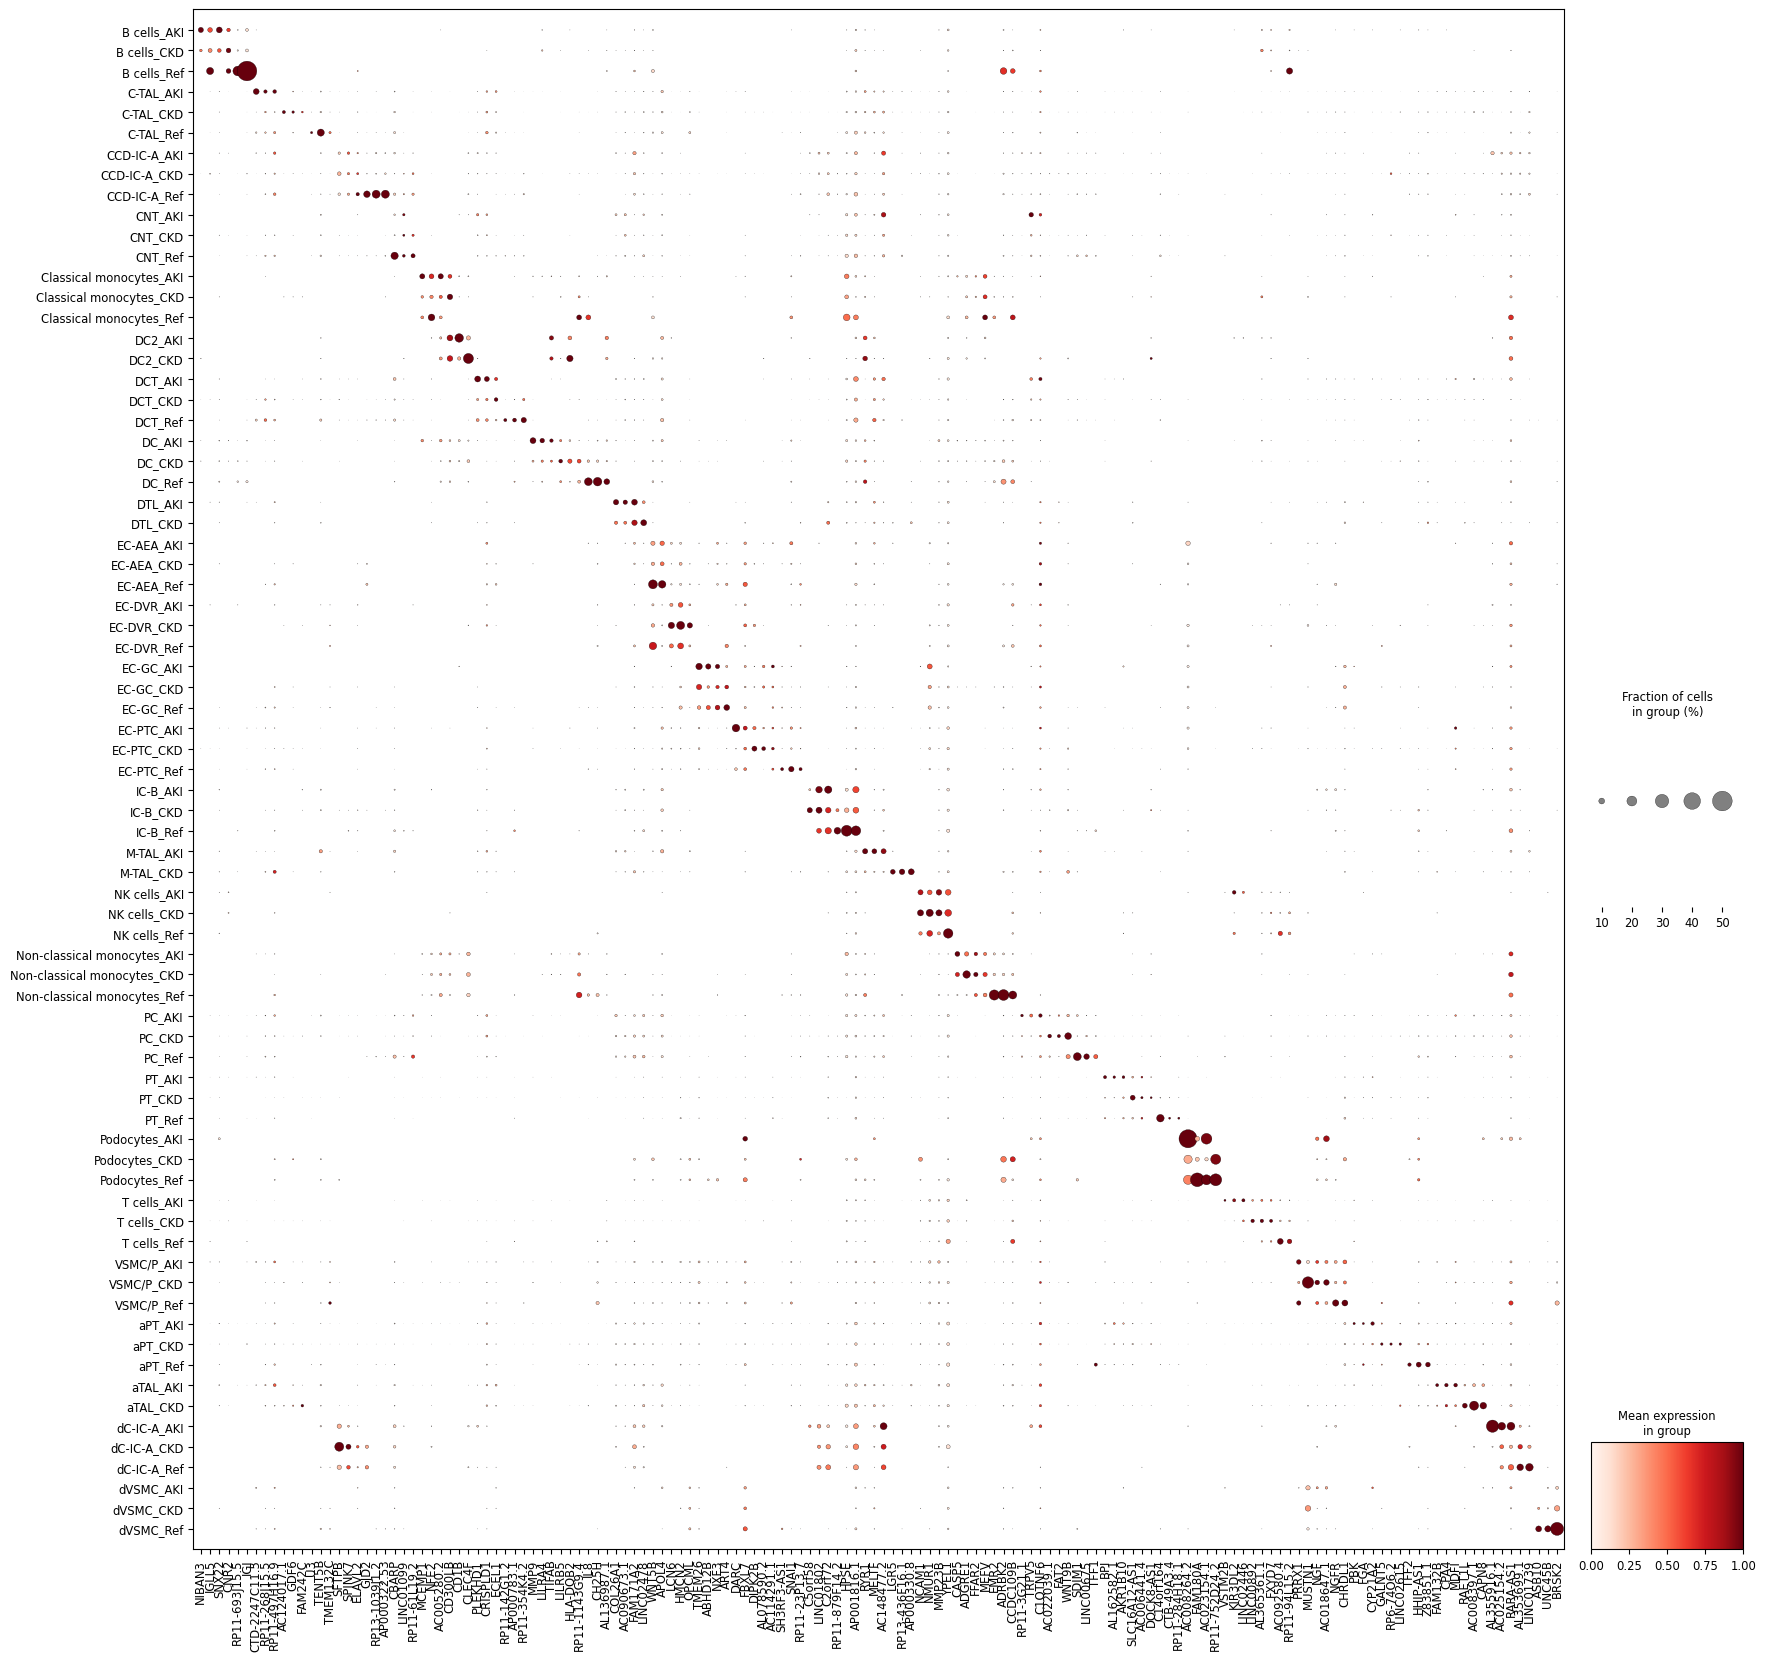

In [17]:
genes_to_plot = unique_markers['names'].tolist()

genes_to_plot = [g for g in genes_to_plot if g in seurat_processed.var_names]
X = seurat_processed[:, genes_to_plot].X
if hasattr(X, "toarray"):
    X = X.toarray()

exp_data = pd.DataFrame(X, index=seurat_processed.obs['majority_voting'], columns=genes_to_plot)
expr_per_group = exp_data.groupby(exp_data.index).sum()

genes_filtered = expr_per_group.columns[(expr_per_group.max(axis=0))>=30].tolist()

expr_per_group = expr_per_group[genes_filtered]

valid_groups = expr_per_group.index[(expr_per_group.sum(axis=1) > 20)].tolist()
seurat_processed1 = seurat_processed[seurat_processed.obs['majority_voting'].isin(valid_groups)].copy()

#seurat_processed1 = seurat_processed[seurat_processed.obs['majority_voting'].isin(valid_groups)].copy()

#sc.pl.dotplot(seurat_processed1, var_names=genes_filtered, groupby="majority_voting", 
 #             standard_scale="var", show=False, figsize=(20,20), dendrogram=False)
sc.pl.dotplot(seurat_processed1, var_names=genes_filtered, groupby='majority_voting', standard_scale='var', show=False, figsize=(20, 20),
    dendrogram=False)

plt.savefig("/media/senthilkumar/New/scRNA-Seq_Workshop/Bonus_data/plots/Cluster_Markergenes.png", dpi=300, bbox_inches='tight')
plt.show()




In [ ]:
seurat_processed.write("/media/senthilkumar/New/scRNA-Seq_Workshop/Bonus_data/output/GSE183276_celltypist.h5ad")

,NIBAN3,IGLL5,SNX22,CNR2,RP11-693J15.5,IGJ,CTD-2247C11.5,RP11-268J15.5,RP11-497H16.9,AC124017.1,...,CAPN8,AL355916.1,AC025154.2,RARA-AS1,AL353699.1,AL451060.1,LINC01739,ASB10,UNC45B,BRSK2
majority_voting,,,,,,,,,,,,,,,,,,,,,
B cells_AKI,77.873567,140.667978,95.489638,45.486804,10.645075,104.604213,1.668830,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
B cells_CKD,34.181494,91.169002,51.656245,67.897201,16.662523,75.730189,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,4.714378,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
B cells_Ref,0.000000,38.943227,0.000000,11.762554,32.439113,133.207944,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
C-TAL_AKI,0.000000,9.449096,26.473853,2.157223,0.000000,1.467997,839.577120,408.956457,418.700538,0.000000,...,27.741484,3.033904,0.000000,46.449220,0.000000,2.852699,44.048088,0.000000,0.000000,2.718766
C-TAL_CKD,0.000000,0.000000,28.620923,0.000000,0.000000,3.366177,11.863937,198.754267,94.194988,519.164985,...,96.239643,5.249167,4.382877,74.815482,1.792592,10.036553,137.860350,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
dC-IC-A_CKD,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.535337,4.845059,3.236548,5.725765,0.000000,3.437009,0.000000,0.000000,0.000000
dC-IC-A_Ref,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,14.436012,24.217252,31.999622,26.164207,40.336606,0.000000,0.574818,0.000000
dVSMC_AKI,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.023635,0.000000,3.222119,0.000000,...,1.930096,1.100073,0.000000,6.624736,0.000000,0.000000,0.000000,0.000000,2.545576,9.438085
